# LAB01 — SVM con pipeline, búsqueda de parámetros y evaluación

**Pregunta de análisis:** ¿Puede un modelo SVM distinguir correctamente entre
tumores malignos y benignos a partir de características morfológicas de
núcleos celulares extraídas de imágenes digitalizadas?

**Unidad de análisis:** cada fila representa una muestra de tejido (imagen
de una masa mamaria), caracterizada por 30 variables numéricas.

**Target:** `diagnosis` — clase binaria (0 = maligno, 1 = benigno).

**⚠️ Advertencia:** este ejercicio es únicamente educativo y NO constituye
un diagnóstico médico ni debe usarse como herramienta clínica real.

In [61]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()
print(X.shape)
print(y.value_counts().sort_index())
X.head()

(569, 30)
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [62]:
audit = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "ausentes": X.isna().sum(),
    "unicos": X.nunique()
})
print("Duplicados:", X.duplicated().sum())
print("Target dentro de X:", y.name in X.columns)
audit.head(10)

Duplicados: 0
Target dentro de X: False


,tipo,ausentes,unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

(455, 30) (114, 30)
target
1    0.626
0    0.374
Name: proportion, dtype: float64
target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [64]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("F1 macro baseline:", f1_score(y_test, dummy_pred, average="macro"))

F1 macro baseline: 0.3870967741935484


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42))
])
svm.fit(X_train, y_train)

c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

ROC-AUC: 0.995


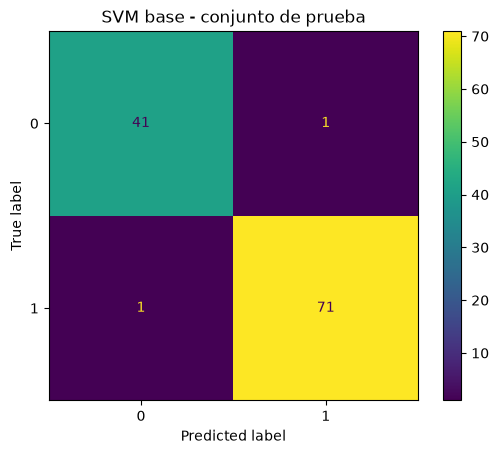

In [66]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("SVM base - conjunto de prueba")
plt.show()

In [67]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    estimator=svm,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(X_train, y_train)
print(search.best_params_)
print("CV:", round(search.best_score_, 4))

{'model__C': 10, 'model__gamma': 0.01}
CV: 0.9739


c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [68]:
cv_results = pd.DataFrame(search.cv_results_)
columns = ["param_model__C", "param_model__gamma",
           "mean_test_score", "std_test_score", "mean_fit_time"]
cv_results[columns].sort_values("mean_test_score", ascending=False).head(9)

best = search.best_estimator_
best_pred = best.predict(X_test)
print(classification_report(y_test, best_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



In [69]:
cv_results[columns].sort_values("mean_test_score", ascending=False).head(9)

,param_model__C,param_model__gamma,mean_test_score,std_test_score,mean_fit_time
7,10.0,0.01,0.973888,0.017677,0.035766
4,1.0,0.01,0.969041,0.016283,0.048533
6,10.0,scale,0.967086,0.013638,0.061625
3,1.0,scale,0.966940,0.015966,0.036969
5,1.0,0.1,0.953323,0.012853,0.076729
1,0.1,0.01,0.942078,0.014347,0.160238
0,0.1,scale,0.937715,0.018035,0.264181
8,10.0,0.1,0.937532,0.023718,0.073214
2,0.1,0.1,0.934135,0.015687,0.075960


In [70]:
from pathlib import Path
print(Path.cwd())

c:\Users\raymi\Documents\INF8239_U01\notebooks


In [71]:
from pathlib import Path
import joblib

reports_dir = Path.cwd().parent / "reports"
reports_dir.mkdir(exist_ok=True)
cv_results[columns].to_csv(reports_dir / "svm_cv_results.csv", index=False)
joblib.dump(best, reports_dir / "svm_best.joblib")
print("Guardado en:", reports_dir.resolve())

Guardado en: C:\Users\raymi\Documents\INF8239_U01\reports


## LAB02 — Dataset propio: enfermedad hepática


In [72]:
import sys
from pathlib import Path

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

print(sys.path[-1])

c:\Users\raymi\Documents\INF8239_U01\src


In [73]:
from pathlib import Path
from inf8239_u01.data import download_csv

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00225/Indian%20Liver%20Patient%20Dataset%20(ILPD).csv"
destination = Path.cwd().parent / "data" / "raw" / "dataset.csv"
path = download_csv(URL, destination=str(destination))
print(path)

c:\Users\raymi\Documents\INF8239_U01\data\raw\dataset.csv


In [74]:
import pandas as pd
from pathlib import Path

column_names = [
    "Age", "Gender", "TB", "DB", "Alkphos", "Sgpt", "Sgot",
    "TP", "ALB", "AG_Ratio", "Selector"
]

dataset_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"
df = pd.read_csv(dataset_path, header=None, names=column_names)

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())
assert not df.empty

(583, 11)
Age           int64
Gender          str
TB          float64
DB          float64
Alkphos       int64
Sgpt          int64
Sgot          int64
TP          float64
ALB         float64
AG_Ratio    float64
Selector      int64
dtype: object
   Age  Gender    TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  AG_Ratio  Selector
0   65  Female   0.7  0.1      187    16    18  6.8  3.3      0.90         1
1   62    Male  10.9  5.5      699    64   100  7.5  3.2      0.74         1
2   62    Male   7.3  4.1      490    60    68  7.0  3.3      0.89         1
3   58    Male   1.0  0.4      182    14    20  6.8  3.4      1.00         1
4   72    Male   3.9  2.0      195    27    59  7.3  2.4      0.40         1
     Age Gender   TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  AG_Ratio  Selector
578   60   Male  0.5  0.1      500    20    34  5.9  1.6      0.37         2
579   40   Male  0.6  0.1       98    35    31  6.0  3.2      1.10         1
580   52   Male  0.8  0.2      245    48    49  6.4  3.2      1

In [75]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "porcentaje_ausente": (df.isna().mean()*100).round(2),
    "unicos": df.nunique(dropna=False)
}).sort_values("porcentaje_ausente", ascending=False)

print("Duplicados:", df.duplicated().sum())
audit

Duplicados: 13


,tipo,ausentes,porcentaje_ausente,unicos
AG_Ratio,float64,4,0.69,70
Gender,str,0,0.00,2
Age,int64,0,0.00,72
TB,float64,0,0.00,113
DB,float64,0,0.00,80
Sgpt,int64,0,0.00,152
Alkphos,int64,0,0.00,263
Sgot,int64,0,0.00,177
TP,float64,0,0.00,58
ALB,float64,0,0.00,40


### Diccionario de datos y hallazgos de la auditoría

| Variable | Significado | Unidad | Momento de disponibilidad | Transformación prevista | Riesgo |
|---|---|---|---|---|---|
| Age | Edad del paciente | Años | Al ingreso | Escalado (StandardScaler) | Bajo |
| Gender | Género | Male/Female | Al ingreso | One-hot encoding | Bajo |
| TB | Bilirrubina total | mg/dL | Resultado de laboratorio | Imputación + escalado | Bajo |
| DB | Bilirrubina directa | mg/dL | Resultado de laboratorio | Imputación + escalado | Bajo |
| Alkphos | Fosfatasa alcalina | UI/L | Resultado de laboratorio | Imputación + escalado | Bajo |
| Sgpt | Alanina aminotransferasa (enzima hepática) | UI/L | Resultado de laboratorio | Imputación + escalado | Bajo |
| Sgot | Aspartato aminotransferasa (enzima hepática) | UI/L | Resultado de laboratorio | Imputación + escalado | Bajo |
| TP | Proteínas totales | g/dL | Resultado de laboratorio | Imputación + escalado | Bajo |
| ALB | Albúmina | g/dL | Resultado de laboratorio | Imputación + escalado | Bajo |
| AG_Ratio | Relación albúmina/globulina | ratio | Resultado de laboratorio (calculado) | Imputación (mediana, 4 ausentes) + escalado | Medio — depende de otros valores de laboratorio |
| Selector | Diagnóstico (target) | 1 = enfermedad hepática, 2 = sin enfermedad | Diagnóstico clínico posterior | Ninguna (es el target) | — |

**Hallazgos de la auditoría:**
- `AG_Ratio` presenta 4 valores ausentes (0.69%), que se imputarán con la mediana dentro del pipeline.
- Se detectaron 13 filas duplicadas. Se decidió **conservarlas**, ya que no hay un identificador de paciente que permita confirmar si son la misma persona registrada dos veces o coincidencias plausibles entre pacientes distintos con perfiles bioquímicos similares. Esta es una limitación documentada del dataset, no un error de carga.
- Todas las variables son observables antes del diagnóstico (resultados de laboratorio de rutina), por lo que el riesgo de fuga de datos es bajo.

In [76]:
TARGET = "Selector"
DROP_COLUMNS = []  # no hay columnas de ID ni fuga evidente en este dataset

assert TARGET in df.columns
X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]
print(y.value_counts(dropna=False))
assert y.notna().all()
assert y.nunique() >= 2

Selector
1    416
2    167
Name: count, dtype: int64


In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                 ("cat", cat_pipe, cat_cols)])

print(len(num_cols), len(cat_cols))
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

9 1
Numéricas: ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AG_Ratio']
Categóricas: ['Gender']


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=.20, random_state=42, stratify=y
)

dummy = Pipeline([("prep", preprocess), ("model", DummyClassifier(strategy="most_frequent"))])
svm = Pipeline([("prep", preprocess), ("model", SVC(C=1, gamma="scale", probability=True, random_state=42))])

for name, model in {"dummy": dummy, "svm": svm}.items():
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    print(name, f1_score(yte, pred, average="macro"))

print(classification_report(yte, svm.predict(Xte)))

dummy 0.415
svm 0.40609137055837563
              precision    recall  f1-score   support

           1       0.70      0.96      0.81        83
           2       0.00      0.00      0.00        34

    accuracy                           0.68       117
   macro avg       0.35      0.48      0.41       117
weighted avg       0.50      0.68      0.58       117



c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [79]:
svm_balanced = Pipeline([
    ("prep", preprocess),
    ("model", SVC(C=1, gamma="scale", probability=True, random_state=42, class_weight="balanced"))
])
svm_balanced.fit(Xtr, ytr)
pred_balanced = svm_balanced.predict(Xte)

print("SVM balanced F1 macro:", f1_score(yte, pred_balanced, average="macro"))
print(classification_report(yte, pred_balanced))

SVM balanced F1 macro: 0.6192307692307693
              precision    recall  f1-score   support

           1       0.91      0.52      0.66        83
           2       0.43      0.88      0.58        34

    accuracy                           0.62       117
   macro avg       0.67      0.70      0.62       117
weighted avg       0.77      0.62      0.64       117



c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [80]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm_search = Pipeline([
    ("prep", preprocess),
    ("model", SVC(probability=True, random_state=42, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    estimator=svm_search,
    param_grid={
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True
)
search.fit(Xtr, ytr)
print(search.best_params_)
print("CV F1-macro:", round(search.best_score_, 4))

best_liver_model = search.best_estimator_
best_pred = best_liver_model.predict(Xte)
print(classification_report(yte, best_pred, digits=4))
print("F1-macro en test:", round(f1_score(yte, best_pred, average="macro"), 4))

{'model__C': 10, 'model__gamma': 'scale'}
CV F1-macro: 0.6265
              precision    recall  f1-score   support

           1     0.9200    0.5542    0.6917        83
           2     0.4478    0.8824    0.5941        34

    accuracy                         0.6496       117
   macro avg     0.6839    0.7183    0.6429       117
weighted avg     0.7828    0.6496    0.6633       117

F1-macro en test: 0.6429


c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


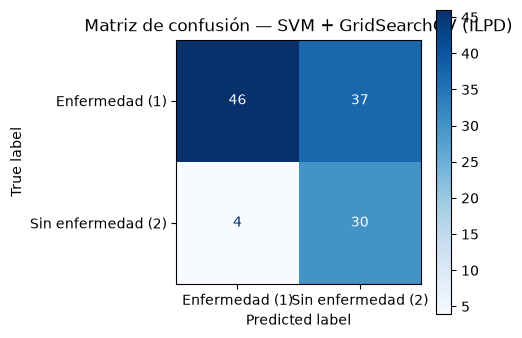

In [81]:
##Matriz de confusión del modelo final (GridSearchCV)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from pathlib import Path

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    yte, best_pred,
    display_labels=["Enfermedad (1)", "Sin enfermedad (2)"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de confusión — SVM + GridSearchCV (ILPD)")
plt.tight_layout()

figures_dir = Path.cwd().parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

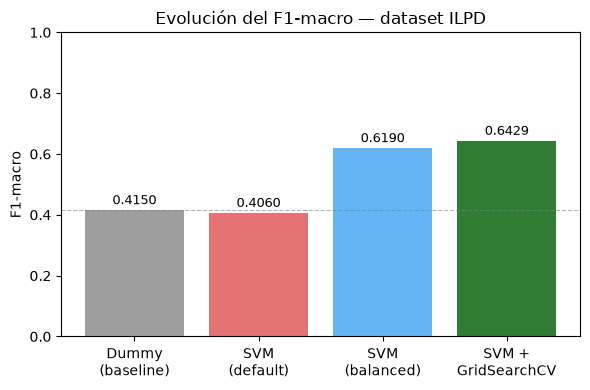

In [82]:
##Comparación de F1-macro entre las 4 versiones del modelo:

import matplotlib.pyplot as plt
from pathlib import Path

modelos = ["Dummy\n(baseline)", "SVM\n(default)", "SVM\n(balanced)", "SVM +\nGridSearchCV"]
f1_scores = [0.415, 0.406, 0.619, 0.6429]  # ajusta si tus valores exactos difieren

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(modelos, f1_scores, color=["#9e9e9e", "#e57373", "#64b5f6", "#2e7d32"])
ax.set_ylabel("F1-macro")
ax.set_ylim(0, 1)
ax.set_title("Evolución del F1-macro — dataset ILPD")
ax.axhline(f1_scores[0], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.4f}",
            ha="center", fontsize=9)

plt.tight_layout()

figures_dir = Path.cwd().parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "f1_macro_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusión

Este laboratorio permitió adaptar el pipeline de clasificación construido en
LAB01 a un dataset propio y real: el Indian Liver Patient Dataset (ILPD) del
repositorio UCI, con el objetivo de apoyar la identificación de pacientes con
probable enfermedad hepática a partir de marcadores bioquímicos de sangre.

El proceso comenzó por formular el problema antes de buscar datos: se definió
el dominio, la unidad de análisis, la decisión que el modelo apoyaría y el
error más costoso (un falso negativo, es decir, no detectar a un paciente
enfermo). Se compararon dos candidatos —el ILPD y el dataset Pima de
diabetes— y se eligió el ILPD por incluir una variable categórica (Género)
que permitía ejercitar el preprocesamiento completo con `ColumnTransformer`,
algo que un dataset puramente numérico no habría permitido.

La descarga se implementó de forma reproducible mediante la función
`download_csv()`, sin depender de rutas personales ni de Google Drive. Sin
embargo, surgió un problema recurrente ya observado en LAB01: al ejecutar la
descarga desde el notebook, el directorio de trabajo correspondía a
`notebooks/` y no a la raíz del proyecto, por lo que el archivo se guardó
inicialmente en una ubicación incorrecta. Se corrigió usando `Path.cwd()`
para construir una ruta absoluta hacia la raíz, la misma estrategia aplicada
previamente para los resultados de LAB01 — confirmando que este es un patrón
de error a tener en cuenta al trabajar con Jupyter.

La auditoría del dataset reveló hallazgos reales: 4 valores ausentes en la
variable `AG_Ratio` (0.69%) y 13 filas duplicadas. Se decidió conservar los
duplicados, documentando la limitación de no contar con un identificador de
paciente que permitiera confirmar si se trataba de registros repetidos o de
coincidencias plausibles entre pacientes distintos.

El hallazgo más relevante ocurrió al comparar el baseline con la SVM: con
hiperparámetros por defecto, la SVM (F1-macro 0.406) tuvo un desempeño
prácticamente idéntico al `DummyClassifier` (F1-macro 0.415), colapsando a
predecir casi siempre la clase mayoritaria (recall de 0% en la clase
minoritaria). Esto evidenció el efecto del desbalance de clases (71%/29%)
sobre un modelo sin ajustar. Al introducir `class_weight="balanced"`, el
F1-macro subió a 0.619 y el recall de la clase minoritaria pasó de 0% a 88%,
aunque a costa de reducir el recall de la clase mayoritaria (de 96% a 52%) —
una tensión real entre el balance estadístico y el error clínicamente más
costoso definido en la ficha del dataset, que merece seguir explorándose en
laboratorios posteriores.

En conjunto, LAB01 y LAB02 documentan un flujo completo y honesto de trabajo
con datos reales: desde la formulación del problema hasta el hallazgo de
limitaciones del modelo, pasando por errores de reproducibilidad
identificados y corregidos de forma transparente.